<a href="https://colab.research.google.com/github/polinaklimenko820-spec/Global-Sales-Analysis/blob/main/Global_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery

project_id = "data-analytics-mate"
client = bigquery.Client(project=project_id)

In [5]:
query = """
SELECT *
FROM `data-analytics-mate.DA.session`
LIMIT 5
"""

df_test = client.query(query).result().to_dataframe(
    create_bqstorage_client=False
)

df_test

,date,ga_session_id
0,2020-11-01,5760483956
1,2020-11-01,7115337200
2,2020-11-01,3978035233
3,2020-11-01,9648986282
4,2020-11-01,4393441533


In [6]:
tables = list(client.list_tables("data-analytics-mate.DA"))

for table in tables:
    print(table.table_id)

ab_test
account
account_session
email_open
email_sent
email_sent_view
email_visit
event_params
order
paid_search_cost
product
revenue_predict
session
session_params
v_WeronikaP_view_task
v_Weronika_view_task
v_email_sent_monthly
v_surname_aggregation_task
v_surname_view_task
widok_do_lookera


In [7]:
table_names = [
    "session",
    "session_params",
    "account_session",
    "account",
    "order",
    "product"
]

for table_name in table_names:
    table = client.get_table(f"data-analytics-mate.DA.{table_name}")

    print(f"\n--- {table_name} ---")
    for field in table.schema:
        print(field.name, "-", field.field_type)


--- session ---
date - DATE
ga_session_id - INTEGER

--- session_params ---
ga_session_id - INTEGER
device - STRING
mobile_model_name - STRING
operating_system - STRING
language - STRING
browser - STRING
continent - STRING
country - STRING
medium - STRING
name - STRING
channel - STRING

--- account_session ---
account_id - INTEGER
ga_session_id - INTEGER

--- account ---
id - INTEGER
send_interval - INTEGER
is_verified - INTEGER
is_unsubscribed - INTEGER

--- order ---
ga_session_id - INTEGER
item_id - INTEGER

--- product ---
item_id - INTEGER
name - STRING
category - STRING
price - FLOAT
short_description - STRING


In [8]:
query = """
SELECT
    s.date AS session_date,
    s.ga_session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,

    acs.account_id,
    a.is_verified,
    a.is_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description

FROM `data-analytics-mate.DA.session` AS s

LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id

LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id

LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id
"""

df = client.query(query).result().to_dataframe(
    create_bqstorage_client=False
)

df.head()

,session_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [10]:
print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество уникальных сессий:")
print(df["ga_session_id"].nunique())

print("\nПериод данных:")
print("От:", df["session_date"].min())
print("До:", df["session_date"].max())

print("\nКоличество пропущенных значений:")
print(df.isnull().sum().sort_values(ascending=False))

Размер датасета: (349545, 18)

Типы данных:
session_date          dbdate
ga_session_id          Int64
continent             object
country               object
device                object
browser               object
mobile_model_name     object
operating_system      object
language              object
traffic_source        object
traffic_channel       object
account_id             Int64
is_verified            Int64
is_unsubscribed        Int64
product_category      object
product_name          object
price                float64
short_description     object
dtype: object

Количество уникальных сессий:
349545

Период данных:
От: 2020-11-01
До: 2021-01-31

Количество пропущенных значений:
is_unsubscribed      321600
is_verified          321600
account_id           321600
short_description    316007
product_name         316007
product_category     316007
price                316007
language             114266
ga_session_id             0
session_date              0
traffic_source        

## 3. Опис датасету

Отриманий датасет містить **349 545 рядків та 18 колонок**.

### Типи даних

- **5 числових колонок:** `ga_session_id`, `account_id`, `is_verified`, `is_unsubscribed`, `price`.
- **12 категоріальних колонок:** `continent`, `country`, `device`, `browser`, `mobile_model_name`, `operating_system`, `language`, `traffic_source`, `traffic_channel`, `product_category`, `product_name`, `short_description`.
- **1 колонка з датою:** `session_date`.

### Сесії та період аналізу

Кількість унікальних сесій становить **349 545**.

Дані охоплюють період з **1 листопада 2020 року до 31 січня 2021 року**.

Кількість рядків дорівнює кількості унікальних `ga_session_id`, тобто кожна сесія в отриманому датасеті представлена одним рядком.

### Пропущені значення

У датасеті присутні пропущені значення.

Найбільше пропусків містять:

- `account_id` — **321 600**
- `is_verified` — **321 600**
- `is_unsubscribed` — **321 600**
- `product_category` — **316 007**
- `product_name` — **316 007**
- `price` — **316 007**
- `short_description` — **316 007**
- `language` — **114 266**

Велика кількість пропусків у `account_id`, `is_verified` та `is_unsubscribed` пояснюється тим, що більшість сесій належать незареєстрованим користувачам.

Пропуски у даних про товари (`product_category`, `product_name`, `price`, `short_description`) виникають у сесіях, під час яких користувач не здійснив замовлення.

Пропущені значення у `language` означають, що інформація про мову браузера доступна не для всіх сесій.

Таким чином, більшість пропущених значень є логічними та пов'язані зі структурою даних, а не обов'язково з помилками їх збору.

In [11]:
orders_check = client.query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT ga_session_id) AS unique_sessions,
    COUNT(DISTINCT item_id) AS unique_products
FROM `data-analytics-mate.DA.order`
""").result().to_dataframe(create_bqstorage_client=False)

orders_check

,total_rows,unique_sessions,unique_products
0,33538,33538,2528


In [12]:
# Топ-3 континенти за сумою продажів
continent_sales = (
    df.dropna(subset=["price"])
      .groupby("continent")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

continent_sales.head(3)

,total_sales,orders
continent,,
Americas,17665280.0,18553
Asia,7601298.3,7950
Europe,5934624.2,6261


In [13]:
# Топ-5 країн за сумою продажів
country_sales = (
    df.dropna(subset=["price"])
      .groupby("country")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

country_sales.head(5)

,total_sales,orders
country,,
United States,13943553.9,14673
India,2809762.0,3029
Canada,2437921.0,2560
United Kingdom,938317.9,1029
France,710692.8,678


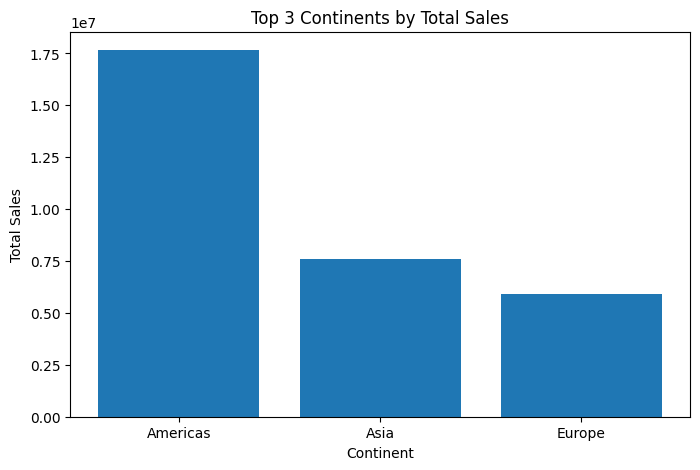

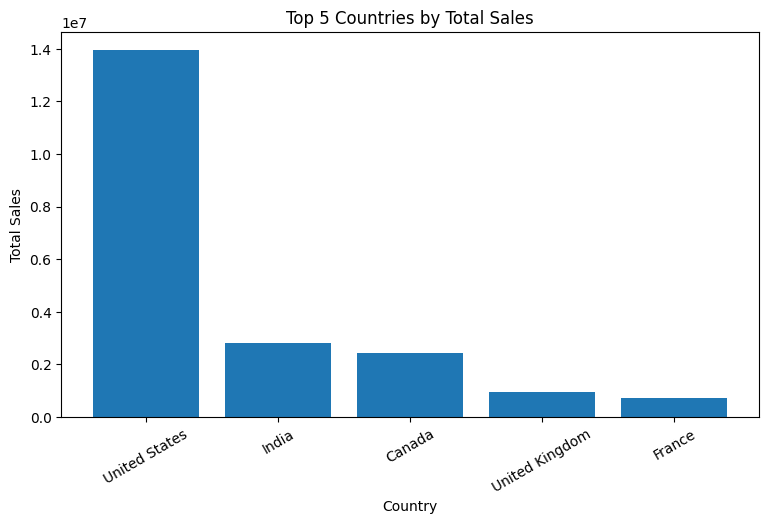

In [14]:
import matplotlib.pyplot as plt

top_continents = continent_sales.head(3)

plt.figure(figsize=(8, 5))
plt.bar(top_continents.index, top_continents["total_sales"])
plt.title("Top 3 Continents by Total Sales")
plt.xlabel("Continent")
plt.ylabel("Total Sales")
plt.show()

top_countries = country_sales.head(5)

plt.figure(figsize=(9, 5))
plt.bar(top_countries.index, top_countries["total_sales"])
plt.title("Top 5 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.show()

### Продажі за континентами та країнами

Найбільший обсяг продажів спостерігається в **Америці** — 17,67 млн, що значно перевищує показники Азії (7,60 млн) та Європи (5,93 млн). Америка також має найбільшу кількість замовлень — 18 553.

Серед країн абсолютним лідером є **США** із загальними продажами 13,94 млн та 14 673 замовленнями. Наступні позиції займають Індія (2,81 млн), Канада (2,44 млн), Велика Британія (0,94 млн) та Франція (0,71 млн).

Результати показують, що значна частина продажів компанії сконцентрована на американському ринку, зокрема у США.

In [15]:
# Топ-10 категорій товарів за загальною сумою продажів
category_sales = (
    df.dropna(subset=["product_category", "price"])
      .groupby("product_category")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

category_sales.head(10)

,total_sales,orders
product_category,,
Sofas & armchairs,8388254.5,4301
Chairs,6147748.8,5952
Beds,4919725.0,2926
Bookcases & shelving units,3640818.1,7630
Cabinets & cupboards,2336499.5,2318
Outdoor furniture,2142222.2,2229
Tables & desks,1790307.5,2941
Chests of drawers & drawer units,906562.5,1452
Bar furniture,735503.0,1092


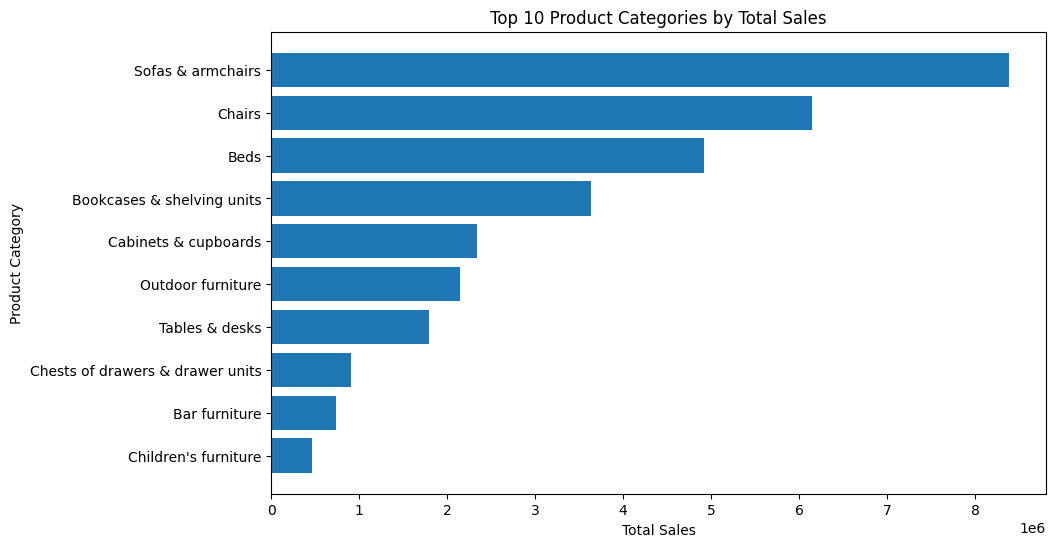

In [16]:
top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories.index[::-1], top_categories["total_sales"][::-1])
plt.title("Top 10 Product Categories by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.show()

### Топ-10 категорій товарів за продажами

Найбільший обсяг продажів припадає на категорію **Sofas & armchairs** — 8,39 млн. Друге місце займає **Chairs** із 6,15 млн, а третє — **Beds** із 4,92 млн.

Водночас найбільша кількість замовлень серед топ-10 категорій спостерігається у **Bookcases & shelving units** — 7 630 замовлень. Незважаючи на це, категорія займає лише четверте місце за сумою продажів (3,64 млн).

Це свідчить про різницю в середній вартості товарів між категоріями: категорії з меншою кількістю замовлень можуть генерувати більший обсяг продажів завдяки вищій ціні товарів.

In [17]:
usa_category_sales = (
    df[
        (df["country"] == "United States") &
        (df["product_category"].notna()) &
        (df["price"].notna())
    ]
    .groupby("product_category")
    .agg(
        total_sales=("price", "sum"),
        orders=("ga_session_id", "nunique")
    )
    .sort_values("total_sales", ascending=False)
)

usa_category_sales.head(10)

,total_sales,orders
product_category,,
Sofas & armchairs,3707144.5,1903
Chairs,2619773.8,2576
Beds,2213058.0,1298
Bookcases & shelving units,1567606.9,3374
Cabinets & cupboards,994545.5,995
Outdoor furniture,929245.2,984
Tables & desks,777865.0,1248
Chests of drawers & drawer units,382388.0,616
Bar furniture,330805.0,487


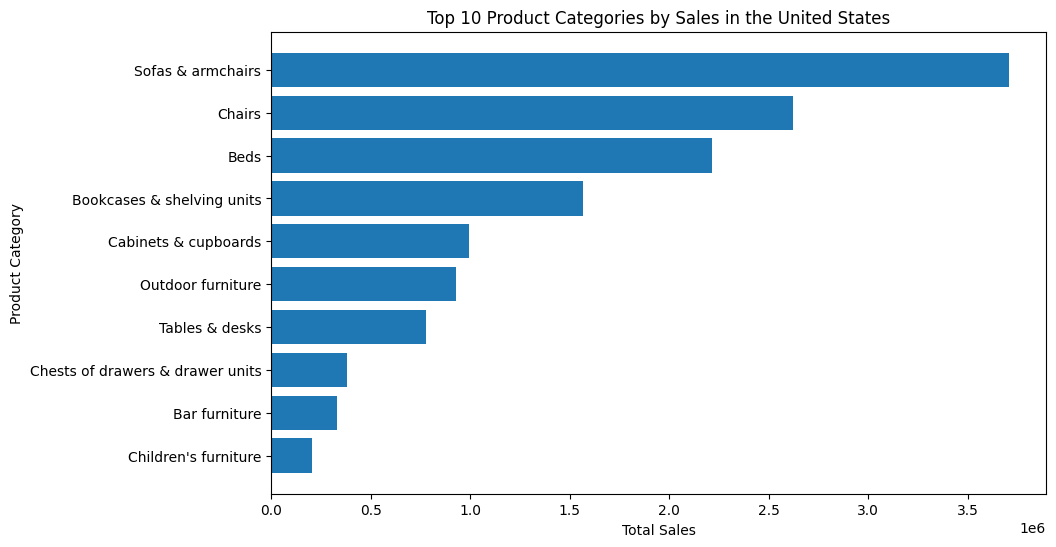

In [18]:
top_usa_categories = usa_category_sales.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_usa_categories.index[::-1],
    top_usa_categories["total_sales"][::-1]
)
plt.title("Top 10 Product Categories by Sales in the United States")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.show()

### Топ-10 категорій товарів у США

США є країною з найбільшим обсягом продажів, тому було додатково проаналізовано структуру продажів за категоріями товарів на цьому ринку.

Топ-10 категорій у США практично повністю повторює загальну структуру продажів. Лідером залишається категорія **Sofas & armchairs** із продажами 3,71 млн, за нею йдуть **Chairs** — 2,62 млн та **Beds** — 2,21 млн.

Категорія **Bookcases & shelving units** також має найбільшу кількість замовлень серед представлених категорій — 3 374, але займає четверте місце за сумою продажів.

Порядок усіх топ-10 категорій у США збігається із загальним рейтингом. Це свідчить про те, що структура попиту на найбільш прибуткові категорії в США загалом відповідає глобальній структурі продажів компанії.

In [19]:
device_sales = (
    df.dropna(subset=["price"])
      .groupby("device")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

device_sales["sales_percentage"] = (
    device_sales["total_sales"] /
    device_sales["total_sales"].sum() * 100
)

device_sales

,total_sales,orders,sales_percentage
device,,,
desktop,18864039.0,19702,59.002245
mobile,12384225.8,13113,38.734924
tablet,723466.3,723,2.262831


In [20]:
model_sales = (
    df.dropna(subset=["price"])
      .groupby("mobile_model_name")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

model_sales["sales_percentage"] = (
    model_sales["total_sales"] /
    model_sales["total_sales"].sum() * 100
)

model_sales.head(10)

,total_sales,orders,sales_percentage
mobile_model_name,,,
Chrome,8899523.9,9359,27.835602
<Other>,6535330.8,6801,20.440966
Safari,6491062.1,6833,20.302504
iPhone,6420776.3,6819,20.082667
ChromeBook,1830458.7,1877,5.725241
Edge,697222.3,741,2.180746
iPad,448854.2,456,1.403910
Firefox,421066.9,430,1.316998
Pixel 4 XL,118287.7,117,0.369976


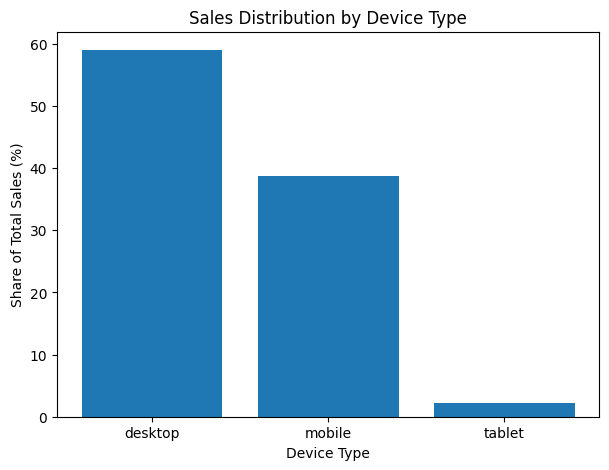

In [21]:
plt.figure(figsize=(7, 5))
plt.bar(device_sales.index, device_sales["sales_percentage"])
plt.title("Sales Distribution by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Share of Total Sales (%)")
plt.show()

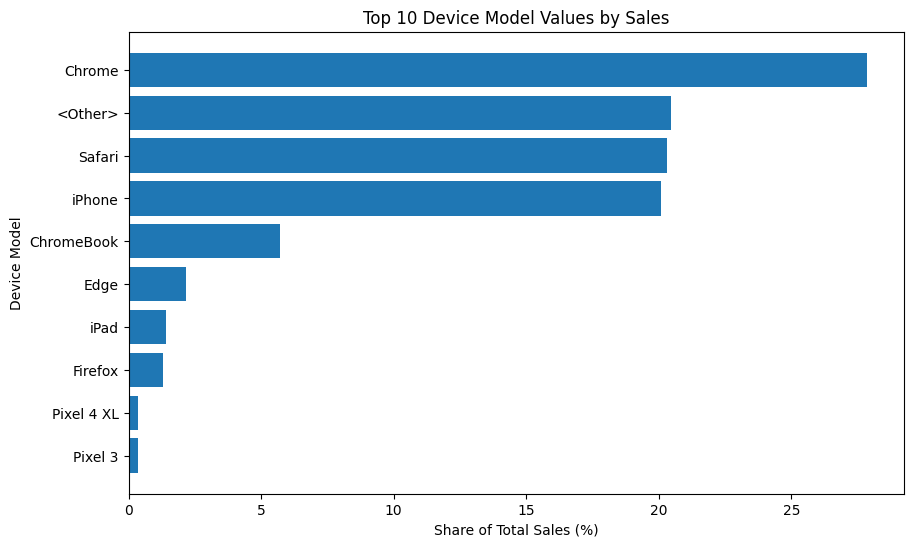

In [22]:
top_models = model_sales.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_models.index[::-1],
    top_models["sales_percentage"][::-1]
)
plt.title("Top 10 Device Model Values by Sales")
plt.xlabel("Share of Total Sales (%)")
plt.ylabel("Device Model")
plt.show()

### Продажі за типами та моделями пристроїв

Найбільша частка продажів припадає на користувачів **desktop — 59,00%** від загального обсягу продажів. На **mobile** припадає **38,73%**, а на **tablet — 2,26%**.

Таким чином, desktop є основним типом пристрою за обсягом продажів, однак mobile також формує значну частину виручки. Це вказує на важливість оптимізації користувацького досвіду як для desktop, так і для mobile.

Серед значень поля `mobile_model_name` найбільшу частку продажів має **Chrome — 27,84%**, далі йдуть **<Other> — 20,44%**, **Safari — 20,30%** та **iPhone — 20,08%**.

Варто зазначити, що поле `mobile_model_name` містить не лише назви моделей пристроїв, але й значення, схожі на назви браузерів, наприклад Chrome, Safari, Edge та Firefox. Тому результати цього поля слід інтерпретувати обережно, оскільки структура вихідних даних може містити особливості або неточності класифікації пристроїв.

In [23]:
traffic_source_sales = (
    df.dropna(subset=["price"])
      .groupby("traffic_source")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

traffic_source_sales["sales_percentage"] = (
    traffic_source_sales["total_sales"] /
    traffic_source_sales["total_sales"].sum() * 100
)

traffic_source_sales

,total_sales,orders,sales_percentage
traffic_source,,,
organic,10935239.9,11430,34.202840
(none),7494923.4,7800,23.442345
referral,5641855.2,6001,17.646386
<Other>,4491351.1,4803,14.047882
(data deleted),2041921.0,2097,6.386645
cpc,1366440.5,1407,4.273902


In [24]:
traffic_channel_sales = (
    df.dropna(subset=["price"])
      .groupby("traffic_channel")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

traffic_channel_sales["sales_percentage"] = (
    traffic_channel_sales["total_sales"] /
    traffic_channel_sales["total_sales"].sum() * 100
)

traffic_channel_sales

,total_sales,orders,sales_percentage
traffic_channel,,,
Organic Search,11433151.6,11921,35.760189
Paid Search,8511049.4,9042,26.620546
Direct,7494923.4,7800,23.442345
Social Search,2532105.7,2716,7.919827
Undefined,2000501.0,2059,6.257093


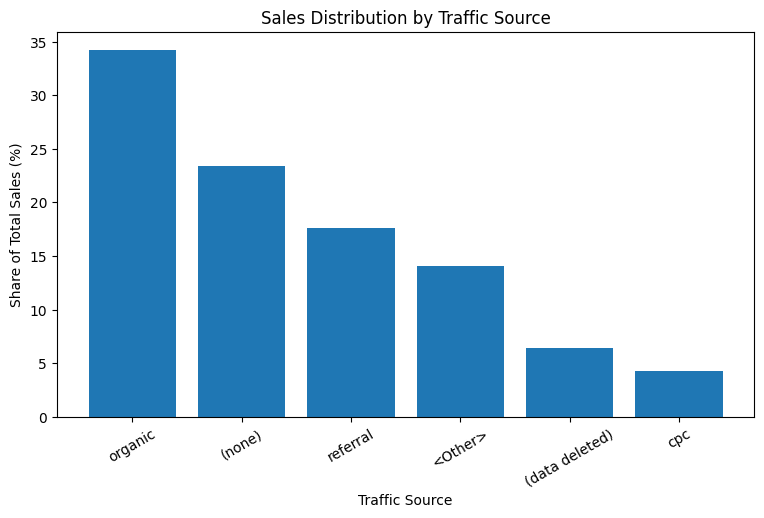

In [25]:
plt.figure(figsize=(9, 5))
plt.bar(
    traffic_source_sales.index,
    traffic_source_sales["sales_percentage"]
)
plt.title("Sales Distribution by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Share of Total Sales (%)")
plt.xticks(rotation=30)
plt.show()

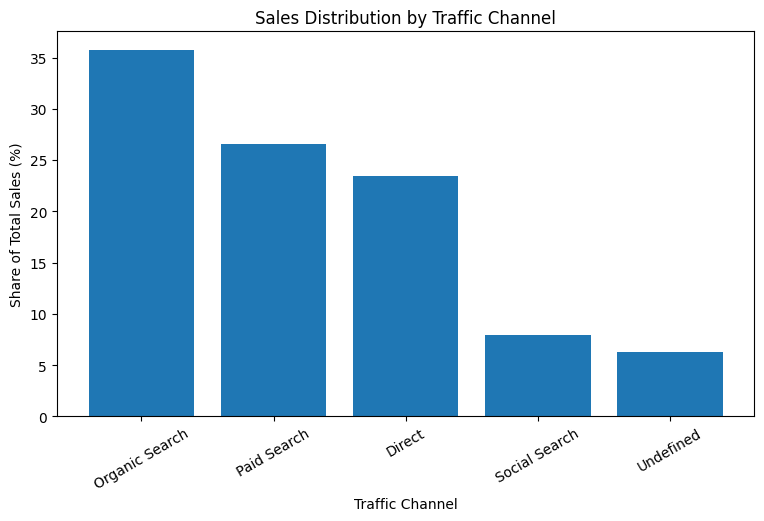

In [26]:
plt.figure(figsize=(9, 5))
plt.bar(
    traffic_channel_sales.index,
    traffic_channel_sales["sales_percentage"]
)
plt.title("Sales Distribution by Traffic Channel")
plt.xlabel("Traffic Channel")
plt.ylabel("Share of Total Sales (%)")
plt.xticks(rotation=30)
plt.show()

### Продажі за джерелами та каналами трафіку

Найбільшу частку продажів серед джерел трафіку генерує **organic — 34,20%** від загального обсягу продажів. Далі йдуть **(none) — 23,44%**, **referral — 17,65%** та **<Other> — 14,05%**. Найменшу частку серед визначених джерел має **cpc — 4,27%**.

У розрізі каналів трафіку найбільшу частку продажів забезпечує **Organic Search — 35,76%**. Друге місце займає **Paid Search — 26,62%**, а третє — **Direct — 23,44%**. На Social Search припадає 7,92%, а на Undefined — 6,26%.

Отримані результати показують, що органічний пошук є найбільшим джерелом продажів. Водночас Paid Search також формує значну частину виручки, тому як органічні, так і платні пошукові канали мають важливе значення для продажів компанії.

Наявність значень `<Other>`, `(data deleted)` та `Undefined` також свідчить про обмеження в деталізації частини даних про джерела трафіку.

In [27]:
registered_users = df.dropna(subset=["account_id"]).drop_duplicates("account_id")

total_registered = registered_users["account_id"].nunique()

verified_percentage = (
    registered_users["is_verified"].eq(1).sum()
    / total_registered * 100
)

unsubscribed_percentage = (
    registered_users["is_unsubscribed"].eq(1).sum()
    / total_registered * 100
)

print("Registered users:", total_registered)
print(f"Verified email: {verified_percentage:.2f}%")
print(f"Unsubscribed: {unsubscribed_percentage:.2f}%")

Registered users: 27945
Verified email: 71.70%
Unsubscribed: 16.94%


In [28]:
subscription_sales = (
    df.dropna(subset=["account_id", "price"])
      .groupby("is_unsubscribed")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique"),
          users=("account_id", "nunique")
      )
)

subscription_sales["sales_per_user"] = (
    subscription_sales["total_sales"] /
    subscription_sales["users"]
)

subscription_sales

,total_sales,orders,users,sales_per_user
is_unsubscribed,,,,
0,2150796.9,2334,2334,921.506812
1,431721.6,447,447,965.820134


### Аналіз зареєстрованих користувачів

У датасеті представлено **27 945 зареєстрованих користувачів**.

Серед них **71,70% підтвердили свою електронну адресу**, а **16,94% відписалися від розсилки**.

Серед зареєстрованих користувачів, які здійснювали покупки, користувачі, що залишилися підписаними на розсилку, згенерували **2,15 млн** продажів, тоді як користувачі, які відписалися, — **0,43 млн**.

Водночас серед користувачів із покупками середній обсяг продажів на одного користувача становить приблизно **921,51** для підписаних та **965,82** для тих, хто відписався.

Таким чином, підписані користувачі формують значно більший загальний обсяг продажів, однак серед покупців відписані користувачі мають дещо вищий обсяг продажів на одного користувача. Для визначення того, чи є ця різниця статистично значущою, необхідний додатковий статистичний аналіз.

In [29]:
registered_by_country = (
    df.dropna(subset=["account_id"])
      .groupby("country")
      .agg(
          registered_users=("account_id", "nunique")
      )
      .sort_values("registered_users", ascending=False)
)

registered_by_country.head(10)

,registered_users
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


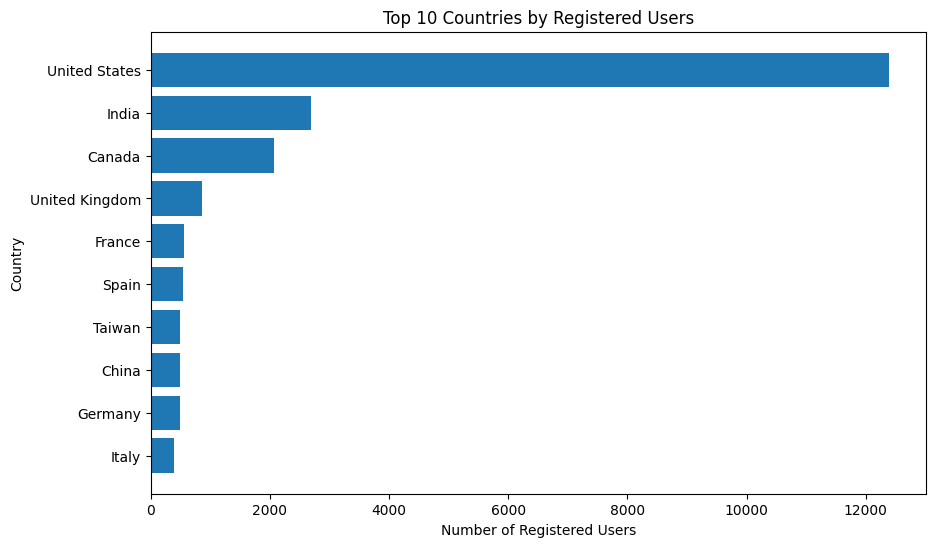

In [30]:
top_registered_countries = registered_by_country.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_registered_countries.index[::-1],
    top_registered_countries["registered_users"][::-1]
)
plt.title("Top 10 Countries by Registered Users")
plt.xlabel("Number of Registered Users")
plt.ylabel("Country")
plt.show()

### Зареєстровані користувачі за країнами

Найбільша кількість зареєстрованих користувачів знаходиться у **США — 12 384 користувачі**. Значно менше зареєстрованих користувачів припадає на Індію — 2 687 та Канаду — 2 067.

До топ-5 також входять Велика Британія — 859 та Франція — 553 зареєстровані користувачі.

США суттєво випереджають інші країни за кількістю зареєстрованих користувачів. Це узгоджується з попереднім аналізом продажів, де США також мають найбільший обсяг продажів та кількість замовлень.

In [33]:
country_avg_order = (
    df.dropna(subset=["price"])
      .groupby("country")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
)

country_avg_order["avg_order_value"] = (
    country_avg_order["total_sales"] /
    country_avg_order["orders"]
)

country_avg_order_filtered = (
    country_avg_order[country_avg_order["orders"] >= 100]
    .sort_values("avg_order_value", ascending=False)
)

country_avg_order_filtered.head(10)

,total_sales,orders,avg_order_value
country,,,
United Arab Emirates,124082.5,107,1159.649533
Philippines,169387.6,150,1129.250667
Belgium,150423.6,135,1114.248889
Vietnam,141975.6,131,1083.783206
Peru,161221.5,152,1060.667763
Thailand,147167.0,139,1058.755396
Poland,318114.0,303,1049.881188
France,710692.8,678,1048.219469
Brazil,339001.8,324,1046.301852


In [32]:
category_avg_order = (
    df.dropna(subset=["product_category", "price"])
      .groupby("product_category")
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
)

category_avg_order["avg_order_value"] = (
    category_avg_order["total_sales"] /
    category_avg_order["orders"]
)

category_avg_order = category_avg_order.sort_values(
    "avg_order_value",
    ascending=False
)

category_avg_order.head(10)

,total_sales,orders,avg_order_value
product_category,,,
Sofas & armchairs,8388254.5,4301,1950.303302
Beds,4919725.0,2926,1681.382433
Chairs,6147748.8,5952,1032.887903
Cabinets & cupboards,2336499.5,2318,1007.980802
Outdoor furniture,2142222.2,2229,961.068730
"Sideboards, buffets & console tables",126330.0,132,957.045455
Room dividers,90288.0,110,820.800000
Bar furniture,735503.0,1092,673.537546
Chests of drawers & drawer units,906562.5,1452,624.354339


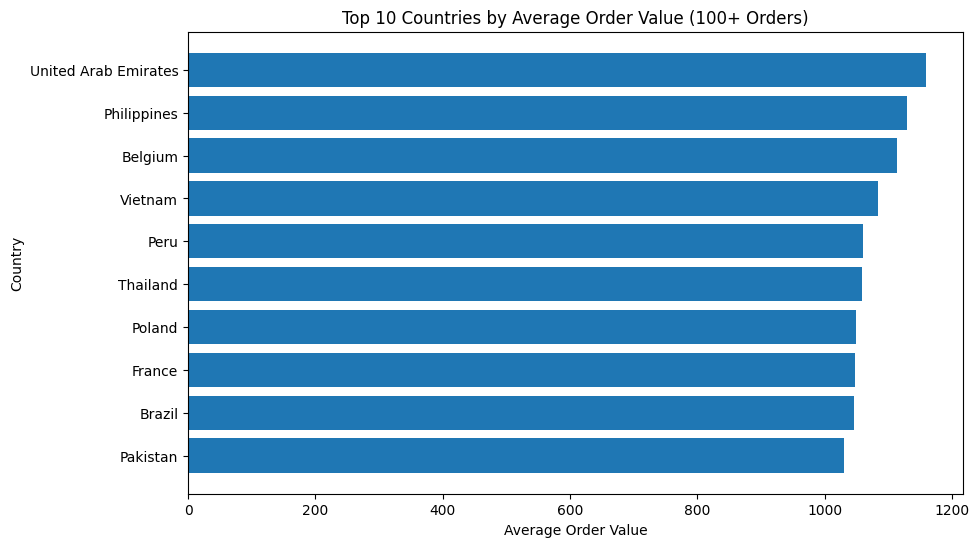

In [34]:
top_avg_countries = country_avg_order_filtered.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_avg_countries.index[::-1],
    top_avg_countries["avg_order_value"][::-1]
)
plt.title("Top 10 Countries by Average Order Value (100+ Orders)")
plt.xlabel("Average Order Value")
plt.ylabel("Country")
plt.show()

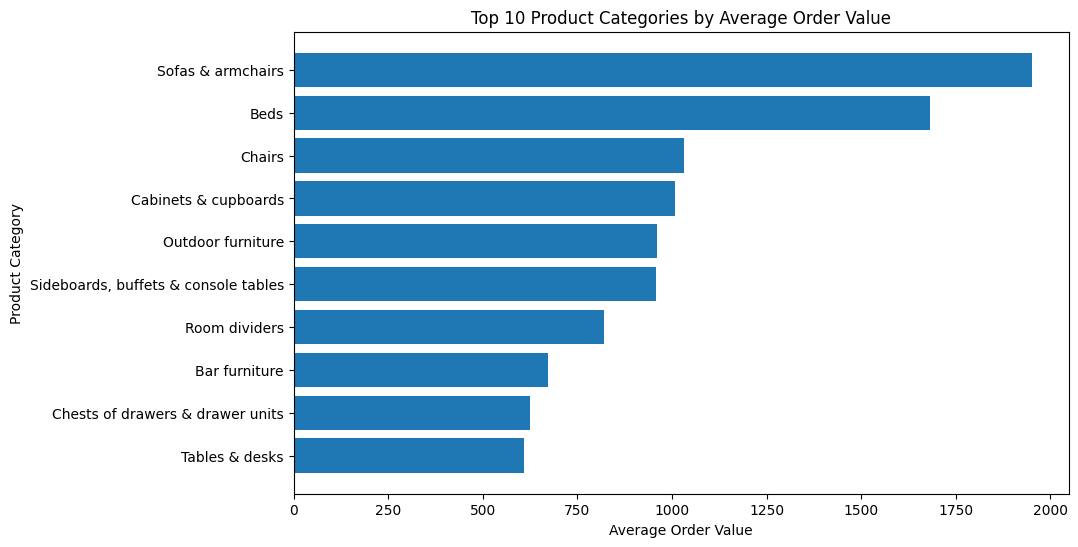

In [35]:
top_avg_categories = category_avg_order.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_avg_categories.index[::-1],
    top_avg_categories["avg_order_value"][::-1]
)
plt.title("Top 10 Product Categories by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Product Category")
plt.show()

### Додаткові інсайти

#### Середня вартість замовлення за країнами

Для більш надійного порівняння було проаналізовано лише країни, в яких здійснено щонайменше 100 замовлень.

Найвища середня вартість замовлення спостерігається в **Об'єднаних Арабських Еміратах — 1 159,65**. Далі йдуть Філіппіни — 1 129,25, Бельгія — 1 114,25 та В'єтнам — 1 083,78.

Використання мінімального порогу в 100 замовлень дозволяє уникнути ситуації, коли країни з дуже малою кількістю покупок потрапляють у топ через декілька дорогих замовлень.

#### Середня вартість замовлення за категоріями товарів

Найвищу середню вартість замовлення має категорія **Sofas & armchairs — 1 950,30**, далі йдуть **Beds — 1 681,38** та **Chairs — 1 032,89**.

Це допомагає пояснити результати попереднього аналізу. Наприклад, категорія `Bookcases & shelving units` мала найбільшу кількість замовлень серед топових категорій, але не була лідером за загальними продажами. Натомість `Sofas & armchairs` має меншу кількість замовлень, але значно вищу середню вартість замовлення, завдяки чому ця категорія генерує найбільший обсяг продажів.

Таким чином, на загальний обсяг продажів впливає не лише кількість замовлень, але й вартість товарів у відповідній категорії.

In [36]:
daily_sales = (
    df.dropna(subset=["price"])
      .groupby("session_date", as_index=False)
      .agg(
          total_sales=("price", "sum"),
          orders=("ga_session_id", "nunique")
      )
      .sort_values("session_date")
)

daily_sales.head()

,session_date,total_sales,orders
0,2020-11-01,244292.5,281
1,2020-11-02,355506.8,368
2,2020-11-03,498979.6,561
3,2020-11-04,339187.1,370
4,2020-11-05,391276.6,388


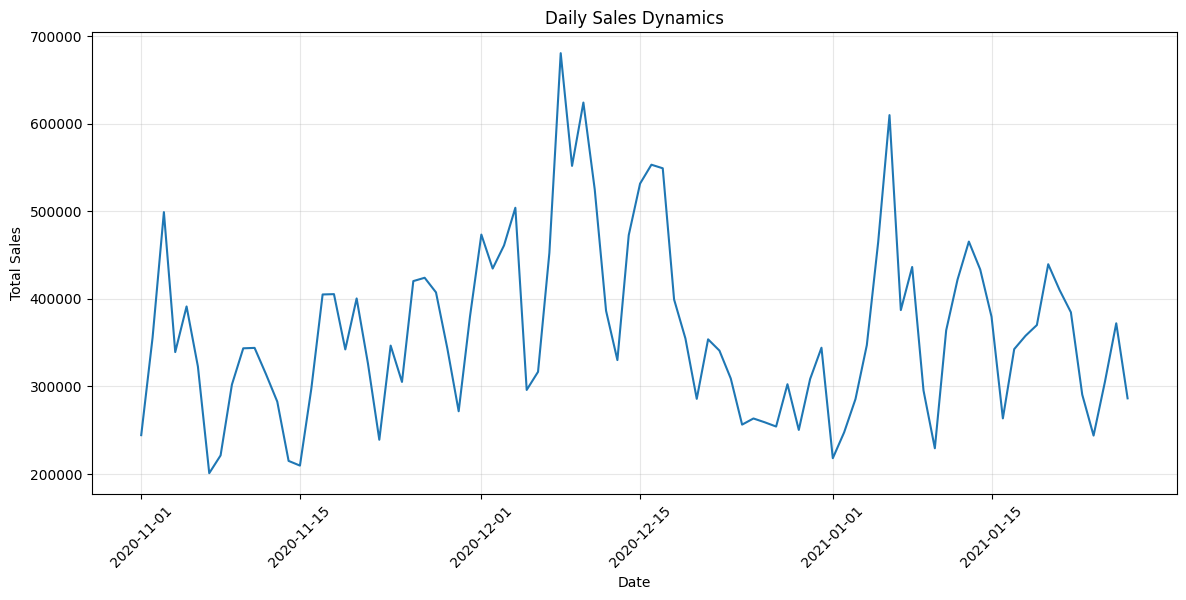

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["session_date"],
    daily_sales["total_sales"]
)

plt.title("Daily Sales Dynamics")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### Загальна динаміка продажів

Щоденні продажі демонструють значні коливання протягом досліджуваного періоду.

Найбільш помітні піки продажів спостерігаються у грудні, а також на початку січня. Водночас між піковими значеннями присутні періоди суттєвого зниження продажів.

На графіку не спостерігається стабільного довгострокового тренду зростання або падіння продажів. Натомість динаміка характеризується регулярними короткостроковими коливаннями та окремими різкими піками.

In [39]:
import pandas as pd

df["session_date"] = pd.to_datetime(df["session_date"])

# Считаем общие продажи за каждый день
daily_sales = (
    df.dropna(subset=["price"])
      .groupby("session_date", as_index=False)
      .agg(total_sales=("price", "sum"))
)

# Определяем день недели
daily_sales["day_of_week"] = daily_sales["session_date"].dt.day_name()

# Считаем средние дневные продажи для каждого дня недели
weekday_sales = (
    daily_sales.groupby("day_of_week")["total_sales"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

weekday_sales

,total_sales
day_of_week,
Monday,356637.723077
Tuesday,419808.915385
Wednesday,420503.300000
Thursday,411411.300000
Friday,376922.266667
Saturday,289832.575000
Sunday,267183.707692


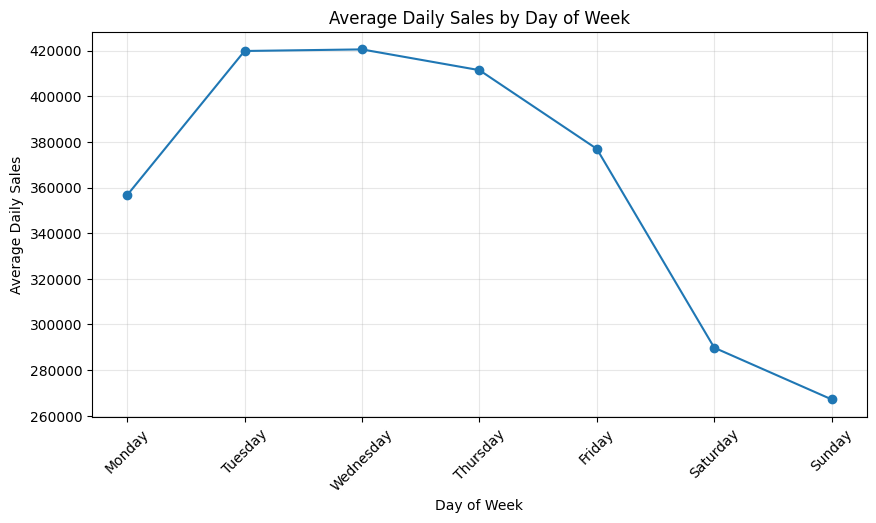

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekday_sales.index,
    weekday_sales.values,
    marker="o"
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### Сезонність продажів

Аналіз середніх денних продажів за днями тижня показує наявність тижневого патерну.

Найвищі середні продажі спостерігаються у **вівторок (419 808,92)** та **середу (420 503,30)**. У четвер рівень продажів також залишається високим — близько **411 411,30**.

Наприкінці тижня продажі знижуються. Найнижчі середні значення спостерігаються у **суботу (289 832,58)** та **неділю (267 183,71)**.

Таким чином, у межах досліджуваного періоду можна спостерігати **тижневий патерн продажів**: активність є вищою у будні, особливо у вівторок–четвер, та нижчою у вихідні.

Оскільки набір даних охоплює лише три місяці, цього недостатньо для надійного висновку про річну сезонність.

In [41]:
continent_daily_sales = (
    df[
        (df["continent"].isin(["Americas", "Asia", "Europe"])) &
        (df["price"].notna())
    ]
    .groupby(["session_date", "continent"], as_index=False)
    .agg(total_sales=("price", "sum"))
)

continent_daily_sales.head()

,session_date,continent,total_sales
0,2020-11-01,Americas,132002.5
1,2020-11-01,Asia,63823.0
2,2020-11-01,Europe,46908.0
3,2020-11-02,Americas,193861.0
4,2020-11-02,Asia,79370.0


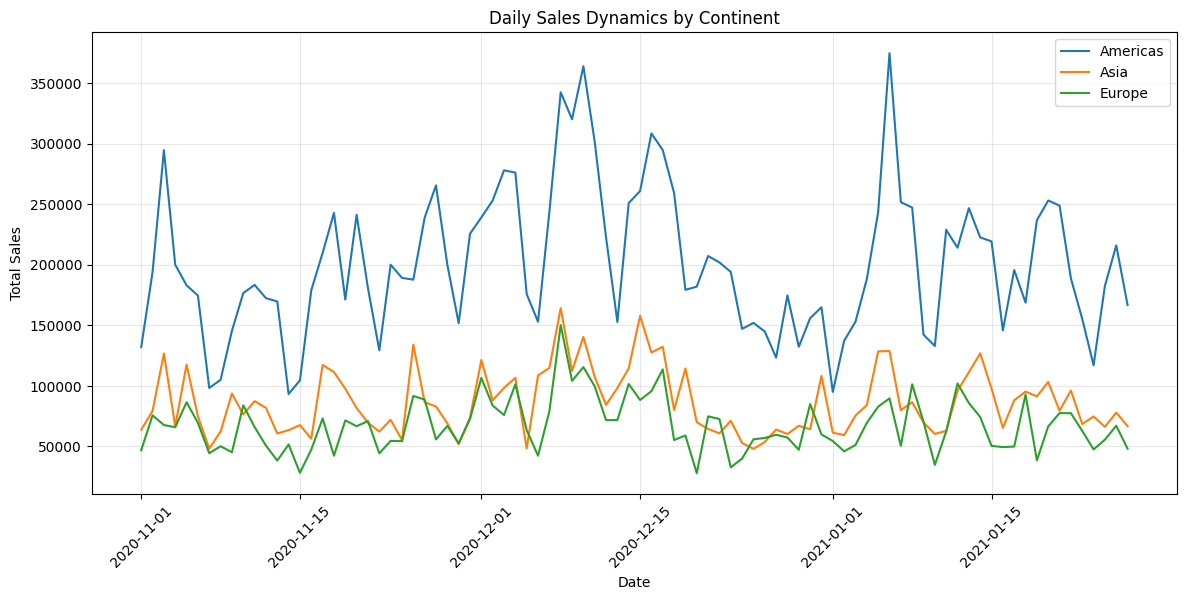

In [42]:
plt.figure(figsize=(14, 6))

for continent in ["Americas", "Asia", "Europe"]:
    data = continent_daily_sales[
        continent_daily_sales["continent"] == continent
    ]

    plt.plot(
        data["session_date"],
        data["total_sales"],
        label=continent
    )

plt.title("Daily Sales Dynamics by Continent")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Динаміка продажів за континентами

Протягом усього досліджуваного періоду **Americas** демонструє найвищий рівень щоденних продажів серед трьох основних регіонів.

Продажі в Americas характеризуються значними коливаннями та найбільш вираженими піками, особливо у грудні та на початку січня. Це узгоджується з попереднім аналізом, де Americas також мав найбільший загальний обсяг продажів.

**Asia** займає друге місце за рівнем продажів, тоді як **Europe** переважно демонструє нижчі значення. Динаміка Asia та Europe є схожою: в окремі дні їхні показники наближаються один до одного, проте Asia здебільшого залишається вище.

Таким чином, загальна динаміка продажів значною мірою залежить від ринку Americas, який є основним джерелом продажів у досліджуваному періоді.

In [43]:
channel_daily_sales = (
    df.dropna(subset=["price"])
      .groupby(["session_date", "traffic_channel"], as_index=False)
      .agg(total_sales=("price", "sum"))
)

channel_daily_sales.head()

,session_date,traffic_channel,total_sales
0,2020-11-01,Direct,54669.5
1,2020-11-01,Organic Search,95112.0
2,2020-11-01,Paid Search,64688.0
3,2020-11-01,Social Search,25078.0
4,2020-11-01,Undefined,4745.0


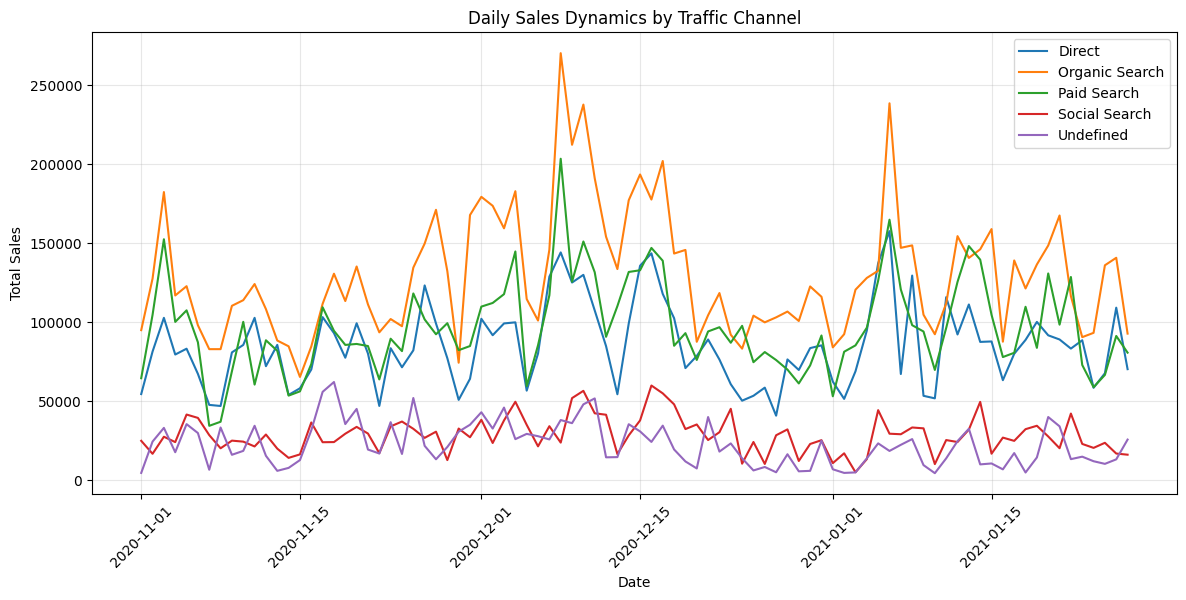

In [44]:
plt.figure(figsize=(14, 6))

for channel in channel_daily_sales["traffic_channel"].unique():
    data = channel_daily_sales[
        channel_daily_sales["traffic_channel"] == channel
    ]

    plt.plot(
        data["session_date"],
        data["total_sales"],
        label=channel
    )

plt.title("Daily Sales Dynamics by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Динаміка продажів за каналами трафіку

Найвищий рівень продажів протягом більшої частини досліджуваного періоду демонструє канал **Organic Search**. Найбільші піки цього каналу спостерігаються у грудні та на початку січня.

**Paid Search** та **Direct** також забезпечують значну частину продажів і мають схожу динаміку з регулярними коливаннями протягом усього періоду.

Канали **Social Search** та **Undefined** демонструють значно нижчі щоденні продажі порівняно з іншими каналами.

Загалом результати підтверджують попередній аналіз: **Organic Search є основним каналом за обсягом продажів**, тоді як Paid Search і Direct також відіграють важливу роль у формуванні загального обсягу продажів.

In [45]:
device_daily_sales = (
    df.dropna(subset=["price"])
      .groupby(["session_date", "device"], as_index=False)
      .agg(total_sales=("price", "sum"))
)

device_daily_sales.head()

,session_date,device,total_sales
0,2020-11-01,desktop,144445.0
1,2020-11-01,mobile,99698.5
2,2020-11-01,tablet,149.0
3,2020-11-02,desktop,206727.3
4,2020-11-02,mobile,137269.5


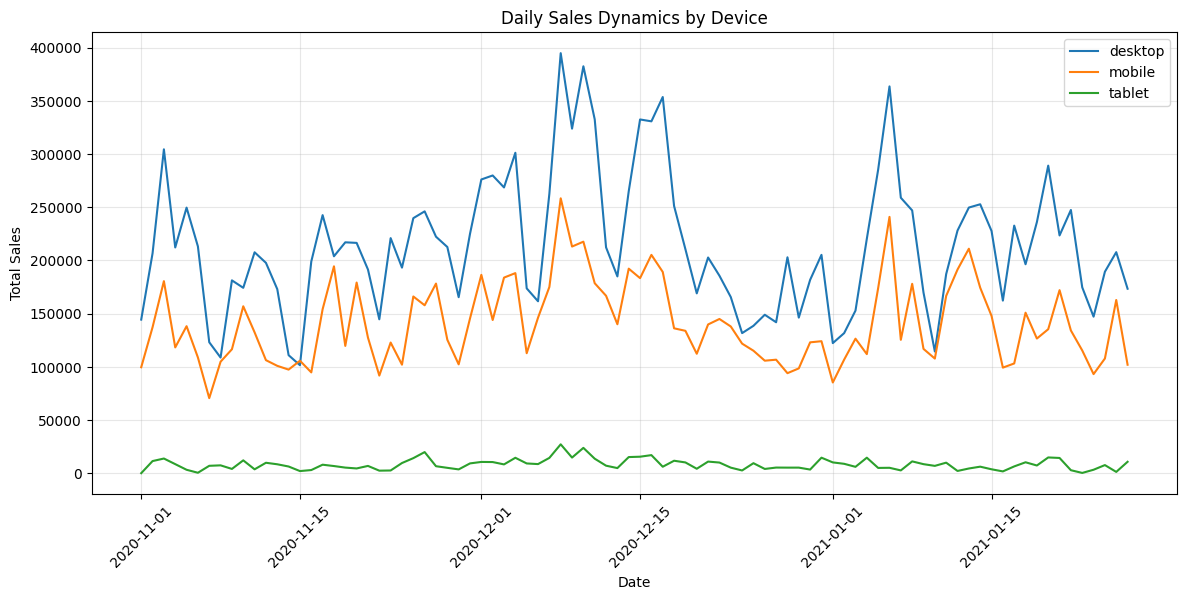

In [46]:
plt.figure(figsize=(14, 6))

for device in device_daily_sales["device"].unique():
    data = device_daily_sales[
        device_daily_sales["device"] == device
    ]

    plt.plot(
        data["session_date"],
        data["total_sales"],
        label=device
    )

plt.title("Daily Sales Dynamics by Device")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Динаміка продажів за типами пристроїв

Протягом усього досліджуваного періоду найбільший обсяг щоденних продажів припадає на **desktop**. Продажі з мобільних пристроїв (**mobile**) займають друге місце, тоді як частка **tablet** є значно меншою.

Динаміка desktop і mobile є схожою: періоди зростання та падіння продажів часто відбуваються одночасно. Найбільш помітні піки спостерігаються у грудні та на початку січня.

Отримані результати узгоджуються з попереднім аналізом структури продажів за пристроями, де desktop забезпечував близько 59% загального обсягу продажів, mobile — близько 39%, а tablet — приблизно 2%.

Таким чином, desktop є основним пристроєм для здійснення покупок, однак mobile також формує значну частину продажів.

In [47]:
pivot_continent_device = pd.pivot_table(
    df,
    values="price",
    index="continent",
    columns="device",
    aggfunc="sum",
    fill_value=0
)

pivot_continent_device

device,desktop,mobile,tablet
continent,,,
(not set),51643.4,22354.0,70.0
Africa,193643.2,130677.8,6910.0
Americas,10497307.4,6780364.3,387608.3
Asia,4381094.4,3028054.4,192149.5
Europe,3493992.9,2311532.8,129098.5
Oceania,246357.7,111242.5,7630.0


### Продажі за континентами та типами пристроїв

Зведена таблиця показує, що **desktop є основним типом пристрою за обсягом продажів у всіх регіонах**.

Найбільші продажі спостерігаються в **Americas**: близько 10,50 млн через desktop та 6,78 млн через mobile. Asia та Europe мають значно менші обсяги, проте структура продажів за пристроями залишається схожою.

Продажі через **tablet** є найнижчими в усіх регіонах.

Також у даних присутня категорія `(not set)`, що вказує на відсутність інформації про континент для частини спостережень.

In [48]:
pivot_category_channel = pd.pivot_table(
    df,
    values="price",
    index="product_category",
    columns="traffic_channel",
    aggfunc="sum",
    fill_value=0
)

pivot_category_channel["Total"] = pivot_category_channel.sum(axis=1)

pivot_category_channel = pivot_category_channel.sort_values(
    "Total",
    ascending=False
)

pivot_category_channel.head(10)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined,Total
product_category,,,,,,
Sofas & armchairs,1990622.0,2925362.0,2214168.5,710012.0,548090.0,8388254.5
Chairs,1454728.0,2192944.6,1658668.6,479799.4,361608.2,6147748.8
Beds,1130173.0,1808148.0,1300249.0,370773.0,310382.0,4919725.0
Bookcases & shelving units,833634.1,1309674.2,986162.2,287311.4,224036.2,3640818.1
Cabinets & cupboards,549938.5,853306.5,617867.5,190254.0,125133.0,2336499.5
Outdoor furniture,542934.8,745654.8,554746.6,156038.4,142847.6,2142222.2
Tables & desks,401744.0,678207.5,479329.0,128628.5,102398.5,1790307.5
Chests of drawers & drawer units,210388.0,309112.0,245290.0,74425.0,67347.5,906562.5
Bar furniture,164452.0,257176.0,195842.0,61183.0,56850.0,735503.0


### Продажі за категоріями товарів та каналами трафіку

Зведена таблиця показує розподіл продажів основних категорій товарів між різними каналами трафіку.

Для більшості найбільших категорій основним каналом продажів є **Organic Search**. Наприклад, у категорії `Sofas & armchairs` через Organic Search було отримано близько 2,93 млн продажів, у `Chairs` — 2,19 млн, а у `Beds` — 1,81 млн.

**Paid Search** переважно займає друге місце, а **Direct** також забезпечує значну частину продажів. Канали `Social Search` та `Undefined` мають значно менший внесок.

Категорія **Sofas & armchairs** залишається лідером за загальним обсягом продажів незалежно від розподілу за каналами трафіку.

In [49]:
pivot_continent_category = pd.pivot_table(
    df,
    values="price",
    index="product_category",
    columns="continent",
    aggfunc="sum",
    fill_value=0
)

pivot_continent_category["Total"] = pivot_continent_category.sum(axis=1)

pivot_continent_category = pivot_continent_category.sort_values(
    "Total",
    ascending=False
)

pivot_continent_category.head(10)

continent,(not set),Africa,Americas,Asia,Europe,Oceania,Total
product_category,,,,,,,
Sofas & armchairs,23345.0,108120.0,4737307.0,1950022.0,1491224.5,78236.0,8388254.5
Chairs,17131.0,44877.0,3309203.0,1524600.8,1178581.0,73356.0,6147748.8
Beds,9565.0,57567.5,2773094.0,1077325.5,925047.5,77125.5,4919725.0
Bookcases & shelving units,2597.0,32996.7,1968919.3,945368.9,650889.5,40046.7,3640818.1
Cabinets & cupboards,5127.0,21106.0,1275562.5,545369.5,468652.5,20682.0,2336499.5
Outdoor furniture,3131.4,16343.8,1213115.2,488607.6,399553.2,21471.0,2142222.2
Tables & desks,7996.0,21658.0,968129.0,464192.5,307045.0,21287.0,1790307.5
Chests of drawers & drawer units,2010.0,10941.0,484290.0,210383.5,186793.0,12145.0,906562.5
Bar furniture,0.0,10724.0,406198.0,176684.0,131110.0,10787.0,735503.0


### Продажі за категоріями товарів та континентами

Зведена таблиця показує, що **Americas має найбільший обсяг продажів у всіх основних категоріях товарів**.

Найбільший внесок у продажі в Americas забезпечують категорії `Sofas & armchairs` — близько 4,74 млн, `Chairs` — 3,31 млн та `Beds` — 2,77 млн.

У **Asia** та **Europe** також найбільші обсяги продажів припадають на ці категорії, що свідчить про схожу структуру попиту в основних регіонах.

Категорія `Sofas & armchairs` є лідером за обсягом продажів у Americas, Asia та Europe. При цьому Americas значно перевищує інші регіони за абсолютним обсягом продажів.

У даних також присутня категорія континенту `(not set)`, яка відповідає спостереженням без визначеного регіону.

In [50]:
correlation_data = df[
    ["price", "is_verified", "is_unsubscribed"]
].dropna()

correlation_matrix = correlation_data.corr()

correlation_matrix

,price,is_verified,is_unsubscribed
price,1.000000,0.011457,0.012335
is_verified,0.011457,1.000000,0.180704
is_unsubscribed,0.012335,0.180704,1.000000


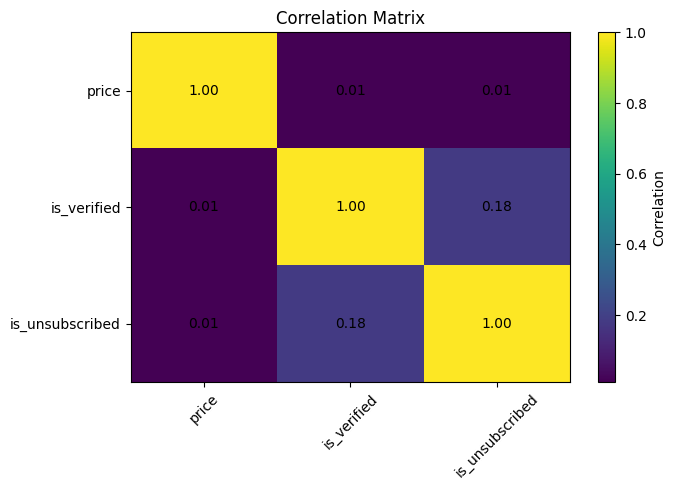

In [51]:
plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Кореляційний аналіз

Кореляційний аналіз показав, що між **ціною товару (`price`)** та статусом верифікації користувача (`is_verified`) практично відсутній лінійний зв'язок: коефіцієнт кореляції становить близько **0,01**.

Аналогічно, між ціною товару та статусом відписки користувача (`is_unsubscribed`) кореляція також становить близько **0,01**, що свідчить про відсутність помітного лінійного зв'язку.

Між `is_verified` та `is_unsubscribed` спостерігається слабка позитивна кореляція — близько **0,18**. Цей зв'язок є невисоким і не свідчить про сильну залежність між показниками.

Таким чином, у досліджуваних числових показниках не виявлено сильних лінійних кореляцій.

In [52]:
subscribed = df[
    (df["is_unsubscribed"] == 0) &
    (df["price"].notna())
]["price"]

unsubscribed = df[
    (df["is_unsubscribed"] == 1) &
    (df["price"].notna())
]["price"]

print("Subscribed:")
print("Count:", len(subscribed))
print("Mean:", subscribed.mean())
print("Median:", subscribed.median())

print("\nUnsubscribed:")
print("Count:", len(unsubscribed))
print("Mean:", unsubscribed.mean())
print("Median:", unsubscribed.median())

Subscribed:
Count: 2334
Mean: 921.5068123393315
Median: 395.0

Unsubscribed:
Count: 447
Mean: 965.8201342281878
Median: 450.0


In [53]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    subscribed,
    unsubscribed,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: the difference is statistically significant.")
else:
    print("Fail to reject H0: the difference is not statistically significant.")

Mann-Whitney U statistic: 500198.0
p-value: 0.16780192609435507
Fail to reject H0: the difference is not statistically significant.


### Статистичний тест: підписані та відписані користувачі

Для перевірки відмінностей у вартості покупок між підписаними та відписаними користувачами було використано **Mann–Whitney U test**.

Середня вартість покупки:
- підписані користувачі — **921,51**;
- відписані користувачі — **965,82**.

Медіанна вартість покупки:
- підписані користувачі — **395**;
- відписані користувачі — **450**.

Було сформульовано такі гіпотези:

**H₀:** розподіл вартості покупок у підписаних та відписаних користувачів не відрізняється.

**H₁:** розподіл вартості покупок у підписаних та відписаних користувачів відрізняється.

За результатами тесту:
- Mann–Whitney U statistic = **500 198**;
- p-value = **0,1678**.

Оскільки **p-value > 0,05**, немає достатніх підстав для відхилення нульової гіпотези.

Таким чином, хоча середня та медіанна вартість покупки у відписаних користувачів дещо вища, **статистично значущої різниці між групами не виявлено**.

In [54]:
desktop_prices = df[
    (df["device"] == "desktop") &
    (df["price"].notna())
]["price"]

mobile_prices = df[
    (df["device"] == "mobile") &
    (df["price"].notna())
]["price"]

print("Desktop:")
print("Count:", len(desktop_prices))
print("Mean:", desktop_prices.mean())
print("Median:", desktop_prices.median())

print("\nMobile:")
print("Count:", len(mobile_prices))
print("Mean:", mobile_prices.mean())
print("Median:", mobile_prices.median())

Desktop:
Count: 19702
Mean: 957.4682265759822
Median: 445.0

Mobile:
Count: 13113
Mean: 944.4235338976589
Median: 435.0


In [55]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    desktop_prices,
    mobile_prices,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: the difference is statistically significant.")
else:
    print("Fail to reject H0: the difference is not statistically significant.")

Mann-Whitney U statistic: 130361108.5
p-value: 0.15860325976935175
Fail to reject H0: the difference is not statistically significant.


### Статистичний тест: Desktop та Mobile

Для перевірки відмінностей у вартості покупок між користувачами desktop та mobile було використано **Mann–Whitney U test**.

Середня вартість покупки:
- desktop — **957,47**;
- mobile — **944,42**.

Медіанна вартість покупки:
- desktop — **445**;
- mobile — **435**.

Було сформульовано такі гіпотези:

**H₀:** розподіл вартості покупок на desktop та mobile не відрізняється.

**H₁:** розподіл вартості покупок на desktop та mobile відрізняється.

За результатами тесту:
- Mann–Whitney U statistic = **130 361 108,5**;
- p-value = **0,1586**.

Оскільки **p-value > 0,05**, немає достатніх підстав для відхилення нульової гіпотези.

Таким чином, хоча середня та медіанна вартість покупки на desktop дещо вища, ніж на mobile, **статистично значущої різниці між цими групами не виявлено**.

Отже, значно більший загальний обсяг продажів через desktop, виявлений у попередньому аналізі, скоріше пов'язаний з більшою кількістю покупок через цей тип пристрою, а не з суттєво вищою вартістю окремої покупки.

## Загальні висновки

У межах аналізу було досліджено продажі за період з листопада 2020 року по січень 2021 року з урахуванням географії, категорій товарів, типів пристроїв, каналів трафіку та характеристик користувачів.

Основні результати:

- **Americas** є найбільшим регіоном за обсягом продажів, а **United States** — країною з найбільшим внеском у загальні продажі.
- Найбільший обсяг продажів генерує категорія **Sofas & armchairs**, тоді як `Bookcases & shelving units` має велику кількість замовлень, але нижчу середню вартість покупки.
- Основним типом пристрою є **desktop**, який забезпечує близько 59% загального обсягу продажів. Mobile також має значну частку — близько 39%.
- Найбільший внесок серед каналів трафіку забезпечує **Organic Search**, за ним ідуть Paid Search та Direct.
- Аналіз динаміки показав значні щоденні коливання продажів та тижневий патерн: середні продажі є вищими у будні та нижчими у вихідні.
- Найвищі середні денні продажі спостерігаються у вівторок та середу, а найнижчі — у суботу та неділю.
- Кореляційний аналіз не виявив сильних лінійних зв'язків між ціною покупки та статусом верифікації або відписки користувача.
- Статистичні тести не виявили статистично значущої різниці у вартості покупок між підписаними та відписаними користувачами, а також між користувачами desktop та mobile.

Загалом результати показують, що основними факторами, пов'язаними із загальним обсягом продажів, є географічна структура аудиторії, популярність товарних категорій, кількість покупок через різні типи пристроїв та канали залучення трафіку.

In [56]:
tableau_df = df.copy()

tableau_df.to_csv(
    "global_sales_tableau.csv",
    index=False
)

print("File created successfully!")
print("Rows:", len(tableau_df))
print("Columns:", len(tableau_df.columns))

File created successfully!
Rows: 349545
Columns: 18


## Tableau Dashboard

Інтерактивний дашборд з результатами аналізу опубліковано в Tableau Public:

[Global Sales Analysis — Tableau Public]
https://public.tableau.com/app/profile/polina.klymenko/viz/GlobalSalesAnalysis_17899265248800/SalesOverview?publish=yes